#### Diplomado - Técnicas Estadísticas y Minería de Datos
#### Módulo II - Modelos Estadísticos
#### Alumno: Sosa Delgadillo Luis Ruben

# Notebook 2: Variables aleatorias


Una variable aleatoria discreta $X$ toma valores en un conjunto finito o infinito numerable. Se caracteriza por su función de probabilidad o masa de probabilidad $p(x) = P(X=x)$, que cumple:

$$p(x) \geq 0 \quad \text{y} \quad \sum_x p(x) = 1$$

## 1. Variable aleatoria uniforme discreta

$X$ sigue una distribución uniforme discreta en el conjunto $\{a, a+1, \dots, b\}$ si todos sus valores son igualmente probables, se denota $X \sim U\{a,b\}$, con $n = b-a+1$ valores posibles.

Función de probabilidad:
$$p(x) = \frac{1}{n}, \qquad x = a, a+1, \dots, b$$

Propiedades:

- Todos los valores tienen la misma probabilidad (equiprobabilidad).

- Es el modelo natural para fenómenos como lanzar un dado o elegir un número al azar de un rango.

Esperanza: $E(X) = \dfrac{a+b}{2}$

Varianza: $Var(X) = \dfrac{n^2-1}{12}$

In [1]:
# Librerías que usaremos a lo largo de todo el notebook
import numpy as np                  # cálculo numérico y generación de números aleatorios
import matplotlib.pyplot as plt     # gráficas
from scipy import stats             # distribuciones de probabilidad ya implementadas (para comparar con nuestras simulaciones)
import sympy as sp

# Configuración estética básica de las gráficas
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

Una variable aleatoria $X$ sigue una distribución uniforme discreta en el conjunto $\{a, a+1, \dots, b\}$ si todos sus valores son igualmente probables. Es el modelo natural para experimentos como lanzar un dado o elegir un número al azar entre varias opciones equiprobables.

Función de probabilidad:
$$p(x) = \frac{1}{b-a+1}, \qquad x = a, a+1, \dots, b$$

Propiedades:
- Todos los valores tienen la misma probabilidad.
- Es simétrica respecto al punto medio $(a+b)/2$.
- El número de valores posibles es $n = b-a+1$.

Esperanza:
$$E(X) = \frac{a+b}{2}$$

Varianza:
$$Var(X) = \frac{(b-a+1)^2 - 1}{12} = \frac{n^2-1}{12}$$


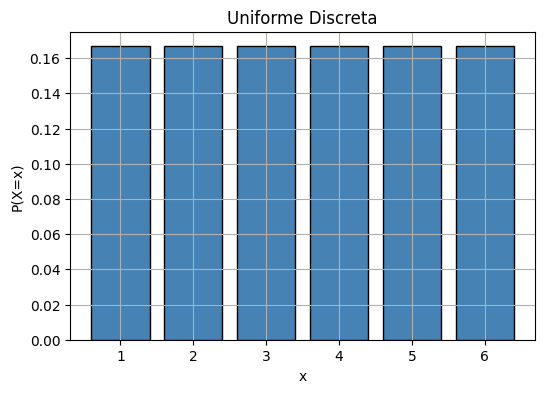

E(X) teórica = 3.5
Var(X) teórica = 2.9167


In [2]:
# Ejemplo: dado justo de 6 caras
a =1
b = 6
x = np.arange(a, b+1)
p = np.full_like(x, 1/(b-a+1), dtype=float)

# Esperanza y varianza teóricas
media_teorica = (a+b)/2
var_teorica = ((b-a+1)**2 - 1)/12

# Gráficamos el modelo
plt.bar(x, p, color="steelblue", edgecolor="black")
plt.xlabel("x"); plt.ylabel("P(X=x)")
plt.title("Uniforme Discreta")
plt.show()

#Imprimimos los resultados
print(f"E(X) teórica = {media_teorica}")
print(f"Var(X) teórica = {var_teorica:.4f}")

Ejercicio:

Se elige al azar un número entero entre 10 y 20, ambos incluidos. 
Calcular $E(X)$, $Var(X)$ y $P(X \leq 15)$.

Solución:

Aquí $a=10$, $b=20$, por lo que $n = b-a+1 = 11$.

- $E(X) = \dfrac{10+20}{2} = 15$
- $Var(X) = \dfrac{11^2-1}{12} = \dfrac{120}{12} = 10$
- $P(X\leq 15)$: hay 6 valores favorables ($10,11,\dots,15$), de 11 posibles, entonces $P(X\leq 15) = \dfrac{6}{11}\approx 0.5455$


In [3]:
# Verificación numérica del ejercicio anterior
a = 10 
b = 20
n = b - a + 1
valores = np.arange(a, b + 1)

E = (a + b) / 2
Var = (n**2 - 1) / 12
P_menor_igual_15 = np.sum(valores <= 15) / n   # contamos valores favorables entre los n posibles

print(f"E(X) = {E}")
print(f"Var(X) = {Var:.2f}")
print(f"P(X<=15) = {P_menor_igual_15:.4f}")

E(X) = 15.0
Var(X) = 10.00
P(X<=15) = 0.5455


### 2. Bernoulli

Modelan un experimento con dos resultados posibles: éxito (1) o fracaso (0), donde $p$ es la probabilidad de éxito. Es el bloque básico a partir del cual se construyen la Binomial, la Geométrica y la Binomial Negativa.

Función de probabilidad:
$$p(x) = p^x (1-p)^{1-x}, \qquad x \in \{0,1\}$$

Propiedades
- Es el caso particular de la Binomial con $n=1$.
- La suma de $n$ Bernoulli i.i.d. con el mismo $p$ es una Binomial $(n,p)$.

Esperanza:
$$E(X) = p$$

Varianza:
$$Var(X) = p(1-p)$$


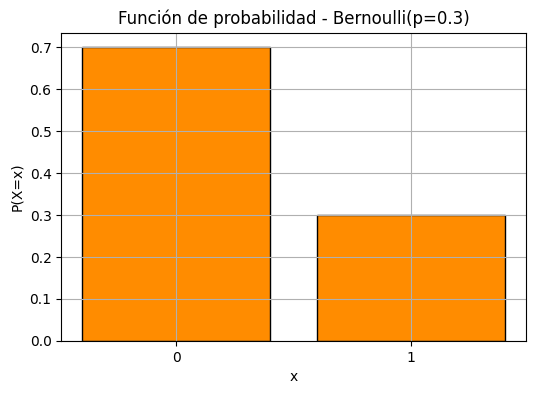

Esperanza teórica: 0.3
Varianza teórica: 0.2100
Media muestral: 0.3130
Varianza muestral: 0.2150


In [4]:
# Ejemplo: lanzar una moneda cargada donde P(cara)=0.3
p = 0.3

# Simulación 1000 ensayos de Bernoulli
np.random.seed(12)
n_sim = 1000

muestra = np.random.binomial(1, p, size=n_sim) # binomial con n=1 ensayo Bernoulli

# Esperanza y varianza teóricas
E_teo = p 
Var_teo = p * (1 - p)

# Graficamos el modelo
valores = [0, 1]
probs = [1 - p, p]
plt.bar(valores, probs, color="darkorange", edgecolor="black")
plt.xticks([0, 1])
plt.title(f"Función de probabilidad - Bernoulli(p={p})")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.show()

# Imprimimos los resultados
print(f"Esperanza teórica: {E_teo}")
print(f"Varianza teórica: {Var_teo:.4f}")
print(f"Media muestral: {muestra.mean():.4f}")
print(f"Varianza muestral: {muestra.var():.4f}")

Ejercicio:

Una máquina tiene una probabilidad de 0.3 de producir una pieza defectuosa. Si $X=1$ indica pieza defectuosa, calcula $E(X)$, $Var(X)$ y estima ambas cantidades simulando 50,000 piezas.

Solución:
$$E(X) = 0.3, \qquad Var(X) = 0.3 \times 0.7 = 0.21$$


In [5]:
p = 0.3
sim = np.random.binomial(1, p, size=50_000)
print(f"Teórico:  E(X) = {p}, Var(X) = {p*(1-p):.4f}")
print(f"Simulado: E(X) = {sim.mean():.4f}, Var(X) = {sim.var():.4f}")

Teórico:  E(X) = 0.3, Var(X) = 0.2100
Simulado: E(X) = 0.2988, Var(X) = 0.2095


### 3. Binomial

Modela el número de éxitos en $n$ ensayos independientes de Bernoulli, cada uno con la misma probabilidad de éxito $p$, se escribe: $X \sim Bin(n,p)$.

Función de probabilidad:

$$p(x) = \binom{n}{x} p^x (1-p)^{n-x}, \qquad x = 0, 1, \dots, n$$

Propiedades:

- Es la suma de $n$ variables Bernoulli($p$) independientes.

- Si $X_1 \sim Bin(n_1,p)$ y $X_2 \sim Bin(n_2,p)$ son independientes, $X_1+X_2 \sim Bin(n_1+n_2, p)$.

- Para $n$ grande y $p$ pequeño se aproxima por una Poisson con $\lambda = np$.

Esperanza:
$$E(X) = np$$

Varianza:
$$Var(X) = np(1-p)$$


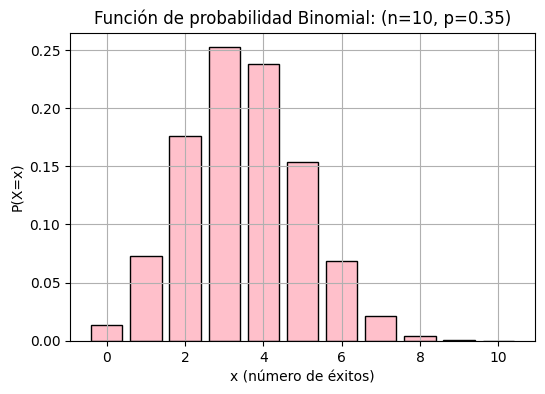

Esperanza teórica: 3.5
Varianza teórica: 2.275


In [6]:
# Ejemplo: número de caras en 10 lanzamientos de una moneda con P(cara)=0.35
n = 10 
p = 0.35
valores = np.arange(0, n + 1)

# Modelo
probabilidades = stats.binom.pmf(valores, n, p)

# Esperanza y varianza teóricas
E_teo = n * p
Var_teo = n * p * (1 - p)

# Graficamos el modelo
plt.bar(valores, probabilidades, color="pink", edgecolor="black")
plt.title(f"Función de probabilidad Binomial: (n={n}, p={p})")
plt.xlabel("x (número de éxitos)")
plt.ylabel("P(X=x)")
plt.show()

# Imprimimos resultados
print(f"Esperanza teórica: {E_teo}")
print(f"Varianza teórica: {Var_teo}")

Ejercicio:

En un examen de opción múltiple con 15 preguntas, cada una con 4 opciones, un estudiante responde al azar. ¿Cuál es la probabilidad de que acierte exactamente 5 preguntas? Calcula también $E(X)$ y $Var(X)$, y compáralo con una simulación.

Solución:

$n=15$, $p=1/4$:
$$P(X=5) = \binom{15}{5}(0.25)^5(0.75)^{10}$$


In [7]:
n = 15
p = 0.25

prob_5 = stats.binom.pmf(5, n, p)
media = n*p
var = n*p*(1-p)

print(f"P(X=5) = {prob_5:.4f}")
print(f"Teórico:  E(X) = {media}, Var(X) = {var:.4f}")

sim = np.random.binomial(n, p, size=100_000)
print(f"Simulado: P(X=5) = {(sim==5).mean():.4f}")
print(f"Simulado: E(X) = {sim.mean():.4f}, Var(X) = {sim.var():.4f}")


P(X=5) = 0.1651
Teórico:  E(X) = 3.75, Var(X) = 2.8125
Simulado: P(X=5) = 0.1674
Simulado: E(X) = 3.7519, Var(X) = 2.8142


### 4. Geométrica

Modela el número de ensayos de Bernoulli ($p$) independientes necesarios hasta obtener el primer éxito. Se escribe $X \sim Geo(p)$, con soporte $x = 1, 2, 3, \dots$

Función de probabilidad:
$$p(x) = (1-p)^{x-1} p, \qquad x = 1, 2, 3, \dots$$

Propiedades:
- Tiene la propiedad de falta de memoria: $P(X > s+t \mid X > s) = P(X > t)$.

- Es un caso particular de la Binomial Negativa con $r=1$.

Esperanza:
$$E(X) = \frac{1}{p}$$

Varianza:
$$Var(X) = \frac{1-p}{p^2}$$


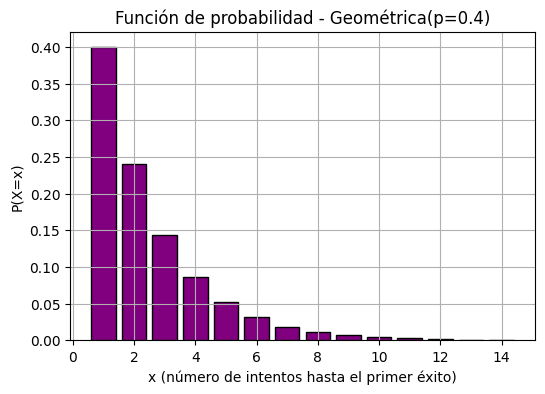

E(X) teórica: 2.5
Var(X) teórica: 3.7500


In [8]:
# Ejemplo: número de intentos hasta anotar un tiro libre, con probabilidad de encestar p=0.4
p = 0.4
valores = np.arange(1, 15)   # mostramos hasta x=14

probabilidades = stats.geom.pmf(valores, p) # Modelo

# Esperanza y varianza teóricas
E_teo = 1 / p
Var_teo = (1 - p) / p**2

# Graficación la función de probabilidad
plt.bar(valores, probabilidades, color="purple", edgecolor="black")
plt.title(f"Función de probabilidad - Geométrica(p={p})")
plt.xlabel("x (número de intentos hasta el primer éxito)")
plt.ylabel("P(X=x)")
plt.show()

# Imprimimos resultados
print(f"E(X) teórica: {E_teo}")
print(f"Var(X) teórica: {Var_teo:.4f}")

Ejercicio:

Un vendedor tiene una probabilidad de 0.2 de cerrar una venta en cada llamada. ¿Cuál es la probabilidad de que la primera venta ocurra exactamente en la cuarta llamada? Calcula $E(X)$, $Var(X)$ y compara con una simulación.

Solución:

$$P(X=4) = (0.8)^3(0.2)$$


In [9]:
p = 0.2
prob_4 = stats.geom.pmf(4, p)
print(f"P(X=4) = {prob_4:.4f}")
print(f"Teórico:  E(X) = {1/p}, Var(X) = {(1-p)/p**2:.4f}")

sim = np.random.geometric(p, size=100_000)
print(f"Simulado: P(X=4) = {(sim==4).mean():.4f}")
print(f"Simulado: E(X) = {sim.mean():.4f}, Var(X) = {sim.var():.4f}")


P(X=4) = 0.1024
Teórico:  E(X) = 5.0, Var(X) = 20.0000
Simulado: P(X=4) = 0.1034
Simulado: E(X) = 5.0191, Var(X) = 20.1192


### 5. Poisson

Modela el número de eventos que ocurren en un intervalo fijo de tiempo o espacio, cuando estos ocurren de manera independiente y con una tasa promedio constante $\lambda$, se escribe: $X \sim Poisson(\lambda)$.

Función de probabilidad:
$$p(x) = \frac{e^{-\lambda}\lambda^x}{x!}, \qquad x = 0, 1, 2, \dots$$

Propiedades:
- $E(X) = Var(X) = \lambda$ (única distribución con esta propiedad).
- La suma de Poisson independientes es Poisson: si $X_1\sim Poisson(\lambda_1)$, $X_2\sim Poisson(\lambda_2)$ independientes, $X_1+X_2 \sim Poisson(\lambda_1+\lambda_2)$.
- Es el límite de una Binomial $(n,p)$ cuando $n\to\infty$, $p\to 0$, con $np=\lambda$ constante.

Esperanza:
$$E(X) = \lambda$$

Varianza:
$$Var(X) = \lambda$$

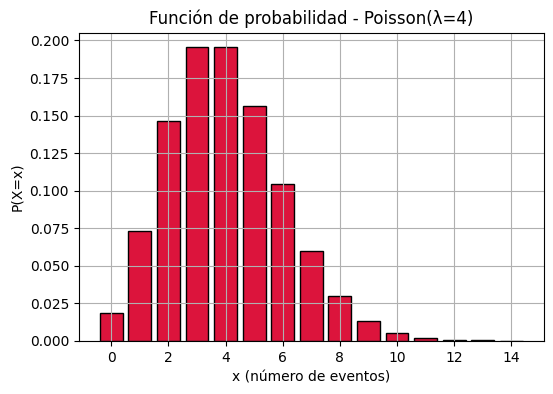

Esperanza teórica: 4
Varianza teórica: 4


In [10]:
# Ejemplo: número de llamadas en un call center por minuto, lambda=4
lam = 4
valores = np.arange(0, 15)

probabilidades = stats.poisson.pmf(valores, lam) # Modelo

# Esperanza y varianza teóricas
E_teo = Var_teo = lam

# Graficación la función de probabilidad
plt.bar(valores, probabilidades, color="crimson", edgecolor="black")
plt.title(f"Función de probabilidad - Poisson(λ={lam})")
plt.xlabel("x (número de eventos)")
plt.ylabel("P(X=x)")
plt.show()

# Imprimimos resultados
print(f"Esperanza teórica: {E_teo}")
print(f"Varianza teórica: {Var_teo}")

Ejercicio:

A una central telefónica llegan en promedio 4 llamadas por minuto. ¿Cuál es la probabilidad de recibir exactamente 6 llamadas en un minuto? Calcula $E(X)$, $Var(X)$ y compara con una simulación.

Solución:

$$P(X=6) = \frac{e^{-4}4^6}{6!}$$


In [11]:
lam = 4
prob_6 = stats.poisson.pmf(6, lam)
print(f"P(X=6) = {prob_6:.4f}")
print(f"Teórico:  E(X) = {lam}, Var(X) = {lam}")

sim = np.random.poisson(lam, size=100_000)
print(f"Simulado: P(X=6) = {(sim==6).mean():.4f}")
print(f"Simulado: E(X) = {sim.mean():.4f}, Var(X) = {sim.var():.4f}")


P(X=6) = 0.1042
Teórico:  E(X) = 4, Var(X) = 4
Simulado: P(X=6) = 0.1043
Simulado: E(X) = 3.9907, Var(X) = 3.9698


### 6. Binomial Negativa

Modela el número de fracasos antes de obtener el $r$-ésimo éxito en una secuencia de ensayos Bernoulli($p$) independientes, se escribe: $X \sim BN(r,p)$.

Función de probabilidad:
$$p(x) = \binom{x+r-1}{x} p^r (1-p)^{x}, \qquad x = 0, 1, 2, \dots$$

Propiedades:
- Con $r=1$ se reduce a la Geométrica (contando fracasos).
- Es la suma de $r$ variables Geométricas independientes (en número de fracasos).
- Sirve para modelar sobredispersión respecto a la Poisson (cuando la varianza observada supera a la media).

Esperanza:
$$E(X) = \frac{r(1-p)}{p}$$

Varianza:
$$Var(X) = \frac{r(1-p)}{p^2}$$


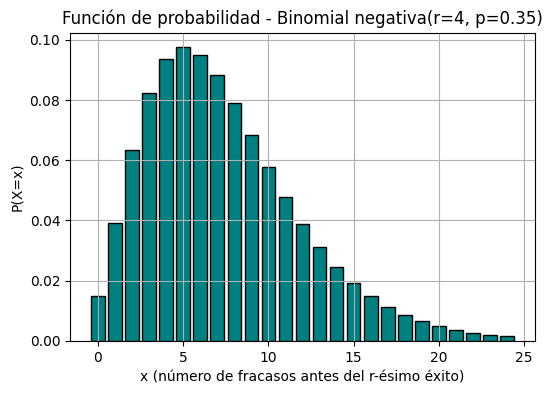

Esperanza teórica: 7.4286
Varianza teórica: 21.2245


In [12]:
# Ejemplo: número de fracasos antes de conseguir r=4 éxitos, con p=0.35 en cada ensayo
r = 4
p = 0.35
valores = np.arange(0, 25)

probabilidades = stats.nbinom.pmf(valores, r, p) # Modelo

# Esperanza y varianza teóricas
E_teo = r * (1 - p) / p
Var_teo = r * (1 - p) / p**2

# Graficamos la función de probabilidad
plt.bar(valores, probabilidades, color="teal", edgecolor="black")
plt.title(f"Función de probabilidad - Binomial negativa(r={r}, p={p})")
plt.xlabel("x (número de fracasos antes del r-ésimo éxito)")
plt.ylabel("P(X=x)")
plt.show()

# Imprimimos los resultados
print(f"Esperanza teórica: {E_teo:.4f}")
print(f"Varianza teórica: {Var_teo:.4f}")

Ejercicio:

Un jugador de baloncesto encesta libres con probabilidad 0.4. ¿Cuál es la probabilidad de que fallé exactamente 5 tiros antes de conseguir su tercer acierto? Calcula $E(X)$, $Var(X)$ y compara con una simulación.

Solución:

Con $r=3$, $p=0.4$:
$$P(X=5) = \binom{5+3-1}{5}(0.4)^3(0.6)^5$$


In [13]:
r = 3
p = 0.4
prob_5 = stats.nbinom.pmf(5, r, p)
print(f"P(X=5) = {prob_5:.4f}")
media = r*(1-p)/p
var = r*(1-p)/p**2
print(f"Teórico:  E(X) = {media:.4f}, Var(X) = {var:.4f}")

sim = np.random.negative_binomial(r, p, size=100_000)
print(f"Simulado: P(X=5) = {(sim==5).mean():.4f}")
print(f"Simulado: E(X) = {sim.mean():.4f}, Var(X) = {sim.var():.4f}")


P(X=5) = 0.1045
Teórico:  E(X) = 4.5000, Var(X) = 11.2500
Simulado: P(X=5) = 0.1056
Simulado: E(X) = 4.5021, Var(X) = 11.2101


### 7. Hipergeométrica

Modela el número de éxitos al extraer una muestra de tamaño $n$ sin reemplazo de una población finita de tamaño $N$, en la que $K$ elementos son de tipo "éxito". A diferencia de la Binomial, aquí los ensayos no son independientes.

Función de probabilidad:
$$p(x) = \frac{\binom{K}{x}\binom{N-K}{n-x}}{\binom{N}{n}}, \qquad x = \max(0, n-N+K), \dots, \min(n,K)$$

Propiedades:
- Cuando $N$ es muy grande respecto a $n$, se aproxima por una Binomial$(n, K/N)$ (el muestreo sin reemplazo se parece al muestreo con reemplazo).
- El factor $\frac{N-n}{N-1}$ en la varianza se llama **factor de corrección para población finita**.

Esperanza:
$$E(X) = n\frac{K}{N}$$

Varianza:
$$Var(X) = n\frac{K}{N}\left(1-\frac{K}{N}\right)\frac{N-n}{N-1}$$


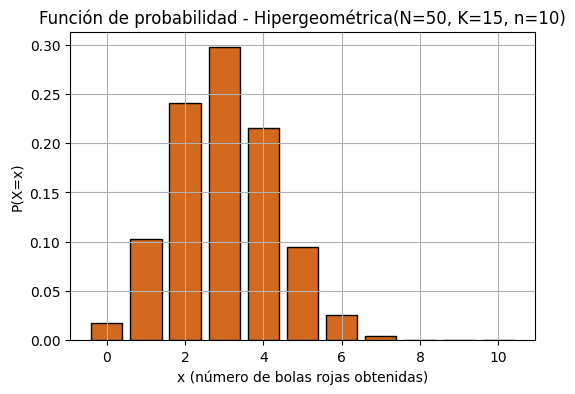

Esperanza teórica: 3.0000
Varianza teórica: 1.7143


In [14]:
# Ejemplo: 
# una urna con N=50 bolas, de las cuales K=15 son rojas. Se extraen n=10 bolas sin reemplazo.
N, K, n = 50, 15, 10
valores = np.arange(0, n + 1)

probabilidades = stats.hypergeom.pmf(valores, N, K, n) #Modelo

# Esperanza y varianza teorica
E_teo = n * K / N
Var_teo = n * (K / N) * ((N - K) / N) * ((N - n) / (N - 1))

# Gráficamos el modelo
plt.bar(valores, probabilidades, color="chocolate", edgecolor="black")
plt.title(f"Función de probabilidad - Hipergeométrica(N={N}, K={K}, n={n})")
plt.xlabel("x (número de bolas rojas obtenidas)")
plt.ylabel("P(X=x)")
plt.show()

# Imprimimos los resultados
print(f"Esperanza teórica: {E_teo:.4f}")
print(f"Varianza teórica: {Var_teo:.4f}")

Ejercicio:

Una caja tiene 50 componentes, de los cuales 20 son defectuosos. Se seleccionan 10 al azar sin reemplazo. ¿Cuál es la probabilidad de obtener exactamente 4 defectuosos? Calcula $E(X)$, $Var(X)$ y compara con una simulación.

Solución:

Con $N=50$, $K=20$, $n=10$:
$$P(X=4) = \frac{\binom{20}{4}\binom{30}{6}}{\binom{50}{10}}$$


In [15]:
N, K, n = 50, 20, 10
prob_4 = stats.hypergeom.pmf(4, N, K, n)
print(f"P(X=4) = {prob_4:.4f}")
media = n*K/N
var = n*(K/N)*(1-K/N)*(N-n)/(N-1)
print(f"Teórico:  E(X) = {media}, Var(X) = {var:.4f}")

sim = np.random.hypergeometric(K, N-K, n, size=100_000)
print(f"Simulado: P(X=4) = {(sim==4).mean():.4f}")
print(f"Simulado: E(X) = {sim.mean():.4f}, Var(X) = {sim.var():.4f}")


P(X=4) = 0.2801
Teórico:  E(X) = 4.0, Var(X) = 1.9592
Simulado: P(X=4) = 0.2814
Simulado: E(X) = 4.0018, Var(X) = 1.9692


## 2. Variables Aleatorias Continuas

Una variable aleatoria continua $X$ toma valores en un intervalo (o unión de intervalos) de números reales, en lugar de una función de probabilidad puntual, se caracteriza por su función de densidad de probabilidad (fdp) $f(x)$, que cumple:

$$f(x) \geq 0, \qquad \int_{-\infty}^{\infty} f(x)\,dx = 1$$

La probabilidad de que $X$ caiga en un intervalo se calcula integrando la densidad:
$$P(a \leq X \leq b) = \int_a^b f(x)\,dx$$

La función de distribución acumulada (CDF) es $F(x) = P(X\leq x) = \int_{-\infty}^x f(t)\,dt$, y la esperanza y varianza se definen como:

$$E(X) = \int_{-\infty}^{\infty} x f(x)\,dx, \qquad Var(X) = E(X^2)-[E(X)]^2$$


### 1. Variable uniforme continua

$X\sim U(a,b)$ si todos los valores en el intervalo $[a,b]$ son "igualmente probables" en el sentido de que la densidad es constante en ese intervalo.

Función de densidad:
$$f(x) = \frac{1}{b-a}, \qquad a \leq x \leq b$$

Función de distribución:
$$F(x) = \begin{cases} 0 & x<a \\ \dfrac{x-a}{b-a} & a\leq x \leq b \\ 1 & x>b \end{cases}$$

Esperanza:
$$E(X) = \frac{a+b}{2}$$

Varianza:
$$Var(X) = \frac{(b-a)^2}{12}$$


E(X) teórica = 5.0, Var(X) teórica = 3.0000


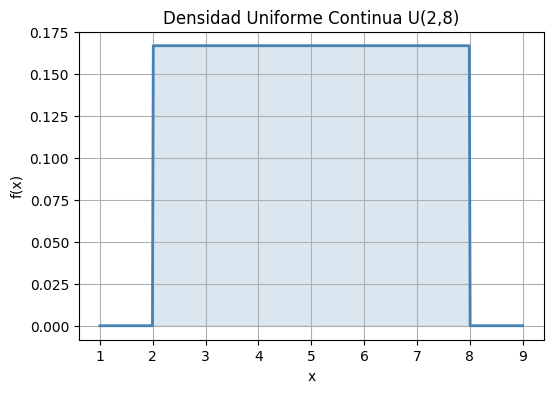

In [16]:
a, b = 2, 8
x = np.linspace(a-1, b+1, 500)
fx = stats.uniform.pdf(x, loc=a, scale=b-a)

#
media = (a+b)/2
var = (b-a)**2/12
print(f"E(X) teórica = {media}, Var(X) teórica = {var:.4f}")

plt.plot(x, fx, color="steelblue", lw=2)
plt.fill_between(x, fx, alpha=0.2, color="steelblue")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title(f"Densidad Uniforme Continua U({a},{b})")
plt.show()


### Simulación y Transformada Inversa
La CDF de $U(a,b)$ es $F(x)=\frac{x-a}{b-a}$. Despejando $x$ de $u=F(x)$ obtenemos la fórmula de inversión:
$$X = a + (b-a)U, \qquad U\sim U(0,1)$$
Esta es, de hecho, la base de cualquier generador de números uniformes: transformamos $U(0,1)$ en $U(a,b)$.


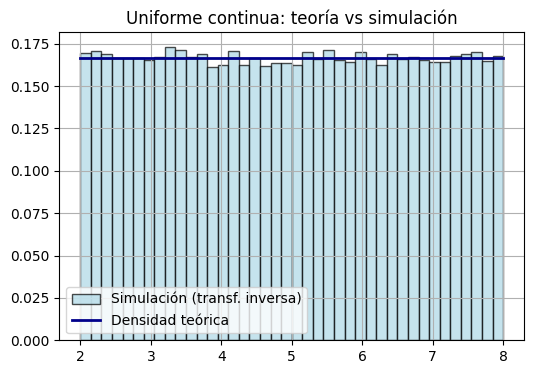

Teórico:  E(X) = 5.0, Var(X) = 3.0000
Simulado: E(X) = 4.9953, Var(X) = 3.0143


In [17]:
np.random.seed(1)
u = np.random.uniform(0, 1, size=100_000)
x_sim = a + (b-a)*u   # transformada inversa

fig, ax = plt.subplots()
ax.hist(x_sim, bins=40, density=True, color="lightblue", edgecolor="black", alpha=0.7, label="Simulación (transf. inversa)")
xx = np.linspace(a, b, 200)
ax.plot(xx, stats.uniform.pdf(xx, loc=a, scale=b-a), color="darkblue", lw=2, label="Densidad teórica")
ax.legend(); ax.set_title("Uniforme continua: teoría vs simulación")
plt.show()

print(f"Teórico:  E(X) = {media}, Var(X) = {var:.4f}")
print(f"Simulado: E(X) = {x_sim.mean():.4f}, Var(X) = {x_sim.var():.4f}")


**Interpretación:** el histograma simulado se ajusta muy bien al rectángulo de altura $1/(b-a)$ que predice la teoría, y la media y varianza muestrales coinciden (con pequeñas diferencias por el error de muestreo) con los valores teóricos $E(X)=5$ y $Var(X)=3$. Esto confirma que la transformada inversa genera correctamente observaciones de una $U(a,b)$.

### 2. Normal

La distribución Normal (o Gaussiana) $X\sim N(\mu,\sigma^2)$ es el modelo continuo más importante en probabilidad y estadística, entre otras razones porque aparece como límite de sumas de variables independientes.

Función de densidad:
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{(x-\mu)^2}{2\sigma^2}}, \qquad x\in\mathbb{R}$$

Función de distribución:
No tiene forma cerrada elemental; se expresa mediante la función $\Phi$ (CDF de la Normal estándar):
$$F(x) = \Phi\!\left(\frac{x-\mu}{\sigma}\right)$$

Esperanza:
$$E(X) = \mu$$

Varianza:
$$Var(X) = \sigma^2$$


E(X) teórica = 0, Var(X) teórica = 1


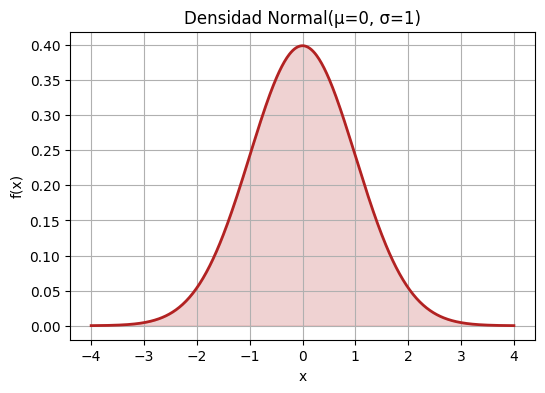

In [18]:
mu, sigma = 0, 1
x = np.linspace(mu-4*sigma, mu+4*sigma, 500)
fx = stats.norm.pdf(x, mu, sigma)

print(f"E(X) teórica = {mu}, Var(X) teórica = {sigma**2}")

plt.plot(x, fx, color="firebrick", lw=2)
plt.fill_between(x, fx, alpha=0.2, color="firebrick")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title(f"Densidad Normal(μ={mu}, σ={sigma})")
plt.show()


### Simulación y Transformada Inversa
La Normal no tiene una CDF invertible en forma cerrada, pero la idea de la transformada inversa sigue funcionando de manera numérica: si $U\sim U(0,1)$, entonces $X=F^{-1}(U)=\Phi^{-1}(U)$ (la función `ppf` de `scipy.stats`, que invierte $\Phi$ numéricamente) tiene distribución $N(\mu,\sigma^2)$.


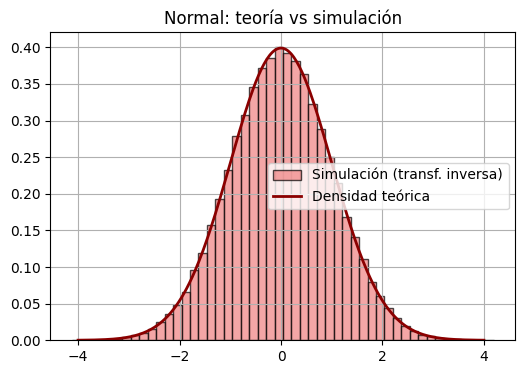

Teórico:  E(X) = 0, Var(X) = 1
Simulado: E(X) = -0.0020, Var(X) = 1.0014


In [19]:
np.random.seed(2)
u = np.random.uniform(0, 1, size=100_000)
x_sim = stats.norm.ppf(u, loc=mu, scale=sigma)   # transformada inversa (numérica)

fig, ax = plt.subplots()
ax.hist(x_sim, bins=50, density=True, color="lightcoral", edgecolor="black", alpha=0.7, label="Simulación (transf. inversa)")
xx = np.linspace(mu-4*sigma, mu+4*sigma, 300)
ax.plot(xx, stats.norm.pdf(xx, mu, sigma), color="darkred", lw=2, label="Densidad teórica")
ax.legend(); ax.set_title("Normal: teoría vs simulación")
plt.show()

print(f"Teórico:  E(X) = {mu}, Var(X) = {sigma**2}")
print(f"Simulado: E(X) = {x_sim.mean():.4f}, Var(X) = {x_sim.var():.4f}")


Interpretación:

El histograma reproduce fielmente la clásica forma de campana, y la media y varianza muestrales están muy próximas a $\mu=0$ y $\sigma^2=1$. Esto ilustra que aplicar la inversa de $\Phi$ a valores uniformes es un método válido (aunque numérico) para simular una Normal.

### 3. Exponencial

Definición:

Modela el tiempo de espera hasta que ocurre un evento, cuando los eventos suceden de forma continua e independiente a una tasa constante $\lambda$ (es el análogo continuo de la Geométrica). Se escribe $X\sim Exp(\lambda)$.

Función de densidad:
$$f(x) = \lambda e^{-\lambda x}, \qquad x \geq 0$$

Función de distribución:
$$F(x) = 1 - e^{-\lambda x}, \qquad x\geq 0$$

Propiedades:
- Tiene la propiedad de **falta de memoria**: $P(X>s+t \mid X>s) = P(X>t)$, igual que la Geométrica.

Esperanza:
$$E(X) = \frac{1}{\lambda}$$

Varianza:
$$Var(X) = \frac{1}{\lambda^2}$$

E(X) teórica = 2.0, Var(X) teórica = 4.0


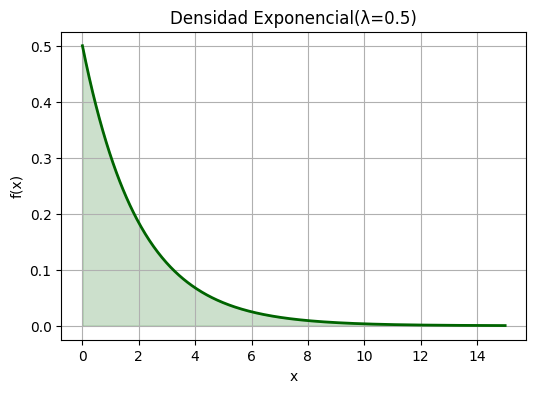

In [29]:
lam = 0.5
x = np.linspace(0, 15, 500)
fx = stats.expon.pdf(x, scale=1/lam)

print(f"E(X) teórica = {1/lam}, Var(X) teórica = {1/lam**2}")

plt.plot(x, fx, color="darkgreen", lw=2)
plt.fill_between(x, fx, alpha=0.2, color="darkgreen")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title(f"Densidad Exponencial(λ={lam})")
plt.show()

Simulación y Transformada Inversa

De $u = F(x) = 1-e^{-\lambda x}$ despejamos:

$$X = -\frac{\ln(1-U)}{\lambda}, \qquad U\sim U(0,1)$$

Como $1-U$ también es $U(0,1)$, en la práctica se suele usar $X=-\ln(U)/\lambda$.


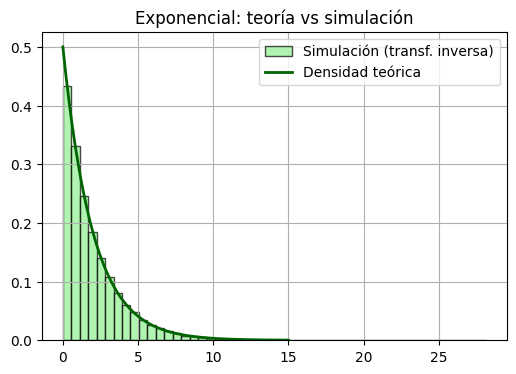

Teórico:  E(X) = 2.0, Var(X) = 4.0
Simulado: E(X) = 2.0095, Var(X) = 4.0427


In [21]:
np.random.seed(3)
u = np.random.uniform(0, 1, size=100_000)
x_sim = -np.log(1-u)/lam   # transformada inversa

fig, ax = plt.subplots()
ax.hist(x_sim, bins=50, density=True, color="lightgreen", edgecolor="black", alpha=0.7, label="Simulación (transf. inversa)")
xx = np.linspace(0, 15, 300)
ax.plot(xx, stats.expon.pdf(xx, scale=1/lam), color="darkgreen", lw=2, label="Densidad teórica")
ax.legend(); ax.set_title("Exponencial: teoría vs simulación")
plt.show()

print(f"Teórico:  E(X) = {1/lam}, Var(X) = {1/lam**2}")
print(f"Simulado: E(X) = {x_sim.mean():.4f}, Var(X) = {x_sim.var():.4f}")


Interpretación:

La simulación reproduce la forma decreciente característica de la exponencial, y sus momentos muestrales se acercan a $E(X)=2$ y $Var(X)=4$. Esto confirma que $-\ln(1-U)/\lambda$ es una fórmula correcta para generar observaciones exponenciales a partir de uniformes.

### 4. Gamma

Generaliza a la Exponencial, es decir, modela el tiempo de espera hasta el $\alpha$-ésimo evento en un proceso de tasa $\beta$ (con $\alpha$ entero, es la suma de $\alpha$ exponenciales independientes), se escribe $X\sim Gamma(\alpha,\beta)$, con $\alpha$ = parámetro de forma y $\beta$ = parámetro de tasa (rate).

Función de densidad:
$$f(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} e^{-\beta x}, \qquad x \geq 0$$

donde: $\Gamma(\alpha)=\int_0^\infty t^{\alpha-1}e^{-t}dt$ es la función Gamma.

Función de distribución:
No tiene forma cerrada elemental para $\alpha$ no entero; se expresa mediante la **función Gamma incompleta regularizada** $F(x) = \frac{\gamma(\alpha,\beta x)}{\Gamma(\alpha)}$.

Propiedades:
- Con $\alpha=1$ se reduce a la Exponencial($\beta$).
- Es la suma de $\alpha$ variables Exponenciales($\beta$) independientes (si $\alpha$ es entero).

Esperanza:
$$E(X) = \frac{\alpha}{\beta}$$

Varianza:
$$Var(X) = \frac{\alpha}{\beta^2}$$


E(X) teórica = 3.0, Var(X) teórica = 3.0


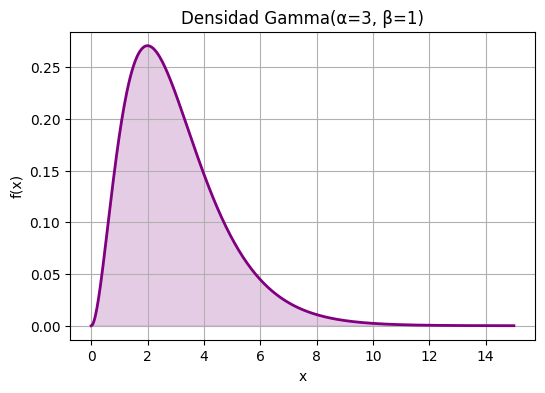

In [22]:
alpha, beta = 3, 1
x = np.linspace(0, 15, 500)
fx = stats.gamma.pdf(x, a=alpha, scale=1/beta)

media = alpha/beta
var = alpha/beta**2
print(f"E(X) teórica = {media}, Var(X) teórica = {var}")

plt.plot(x, fx, color="purple", lw=2)
plt.fill_between(x, fx, alpha=0.2, color="purple")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title(f"Densidad Gamma(α={alpha}, β={beta})")
plt.show()


Simulación y Transformada Inversa

La CDF de la Gamma no es invertible con una fórmula elemental (a diferencia de la Uniforme o la Exponencial). Sin embargo, el principio de la transformada inversa sigue aplicándose: usamos la inversa numérica de $F$ para cada $u$. Cuando $\alpha$ es entero, otra alternativa exacta es sumar $\alpha$ exponenciales generadas por transformada inversa.


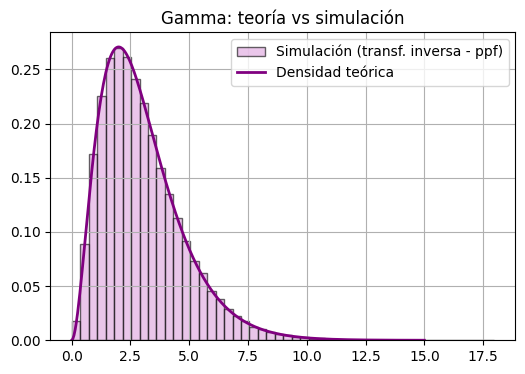

Teórico:              E(X) = 3.0, Var(X) = 3.0
Simulado (ppf):       E(X) = 3.0027, Var(X) = 3.0263
Simulado (suma exp):  E(X) = 3.0048, Var(X) = 3.0142


In [23]:
np.random.seed(4)
u = np.random.uniform(0, 1, size=100_000)
x_sim = stats.gamma.ppf(u, a=alpha, scale=1/beta)   # transformada inversa numérica

# Verificación alternativa: suma de 'alpha' exponenciales (método exacto para alpha entero)
exp_sum = -np.log(np.random.uniform(0,1, size=(alpha, 100_000))).sum(axis=0) / beta

fig, ax = plt.subplots()
ax.hist(x_sim, bins=50, density=True, color="plum", edgecolor="black", alpha=0.6, label="Simulación (transf. inversa - ppf)")
xx = np.linspace(0, 15, 300)
ax.plot(xx, stats.gamma.pdf(xx, a=alpha, scale=1/beta), color="purple", lw=2, label="Densidad teórica")
ax.legend(); ax.set_title("Gamma: teoría vs simulación")
plt.show()

print(f"Teórico:              E(X) = {media}, Var(X) = {var}")
print(f"Simulado (ppf):       E(X) = {x_sim.mean():.4f}, Var(X) = {x_sim.var():.4f}")
print(f"Simulado (suma exp):  E(X) = {exp_sum.mean():.4f}, Var(X) = {exp_sum.var():.4f}")


Interpretación:

Ambos métodos de simulación (la inversa numérica de la CDF y la suma de $\alpha$ exponenciales) producen histogramas y momentos consistentes con la densidad teórica ($E(X)=3$, $Var(X)=3$), lo que valida numéricamente la propiedad de que una Gamma$(\alpha,\beta)$ con $\alpha$ entero es la suma de $\alpha$ Exponenciales($\beta$) independientes.

## 3. Simulación de Variables Aleatorias (FGM, FC, LGN y TCL)

Dos herramientas teóricas que resumen por completo una distribución, es decir la función generadora de momentos y la función característica, y dos resultados que explican por qué las simulaciones funcionan y por qué la distribucion normal aparece tan frecuentemente: la Ley de los Grandes Números y el Teorema Central del Límite.


### 1. Función Generadora de Momentos (FGM)

$$M_X(t) = E(e^{tX})$$

Definida para los valores de $t$ en un entorno de 0 donde la esperanza existe (converge).

Propiedades:
- Unicidad: si dos variables tienen la misma FGM en un entorno de 0, tienen la misma distribución.
- Generador de momentos: derivando y evaluando en $t=0$ se obtienen los momentos:
$$E(X^n) = M_X^{(n)}(0)$$
  En particular $E(X)=M_X'(0)$ y $E(X^2)=M_X''(0)$, de donde $Var(X)=M_X''(0)-[M_X'(0)]^2$.
- Cambio de escala: $M_{aX+b}(t) = e^{bt}M_X(at)$.
- Suma de independientes: si $X$ y $Y$ son independientes, $M_{X+Y}(t) = M_X(t)\,M_Y(t)$.
- No siempre existe (algunas distribuciones de colas pesadas no tienen FGM), por eso la Función Característica es más general.

Ejemplo: FGM de la Exponencial($\lambda$)

$$M_X(t) = E(e^{tX}) = \int_0^\infty e^{tx}\lambda e^{-\lambda x}dx = \frac{\lambda}{\lambda - t}, \qquad t < \lambda$$

Derivando:
$$M_X'(t) = \frac{\lambda}{(\lambda-t)^2} \;\Rightarrow\; E(X) = M_X'(0) = \frac{1}{\lambda}$$
$$M_X''(t) = \frac{2\lambda}{(\lambda-t)^3} \;\Rightarrow\; E(X^2) = M_X''(0) = \frac{2}{\lambda^2} \;\Rightarrow\; Var(X) = \frac{2}{\lambda^2}-\frac{1}{\lambda^2}=\frac{1}{\lambda^2}$$

que coincide con los valores conocidos de la Exponencial.


In [24]:
# Verificación simbólica con sympy: derivamos la FGM de la Exponencial(λ)
t, lam_s = sp.symbols('t lambda', positive=True)
M = lam_s / (lam_s - t)

M1 = sp.diff(M, t).subs(t, 0)   # E(X)
M2 = sp.diff(M, t, 2).subs(t, 0)  # E(X^2)

print("M'(0)  = E(X)   =", sp.simplify(M1))
print("M''(0) = E(X^2) =", sp.simplify(M2))
print("Var(X) = E(X^2) - E(X)^2 =", sp.simplify(M2 - M1**2))


M'(0)  = E(X)   = 1/lambda
M''(0) = E(X^2) = 2/lambda**2
Var(X) = E(X^2) - E(X)^2 = lambda**(-2)


In [25]:
# Comparación teoría vs simulación: momentos de la Exponencial(λ=0.5) vía transformada inversa
lam = 0.5
np.random.seed(5)
u = np.random.uniform(0, 1, size=200_000)
x_sim = -np.log(1-u)/lam   # transformada inversa

EX_teorico  = 1/lam
EX2_teorico = 2/lam**2
Var_teorico = 1/lam**2

print("             Teórico   Simulado")
print(f"E(X):        {EX_teorico:.4f}    {x_sim.mean():.4f}")
print(f"E(X^2):      {EX2_teorico:.4f}    {(x_sim**2).mean():.4f}")
print(f"Var(X):      {Var_teorico:.4f}    {x_sim.var():.4f}")


             Teórico   Simulado
E(X):        2.0000    2.0027
E(X^2):      8.0000    8.0147
Var(X):      4.0000    4.0039


Interpretación:

Los momentos obtenidos derivando la FGM ($E(X)=1/\lambda$, $E(X^2)=2/\lambda^2$) coinciden con los momentos estimados a partir de una muestra simulada por transformada inversa. Esto confirma que la FGM efectivamente "genera" los momentos de la distribución y que nuestro método de simulación es consistente con la teoría.

### 2. Función Característica (FC)

$$\varphi_X(t) = E(e^{itX}) = E(\cos(tX)) + i\,E(\sin(tX))$$

donde: $i=\sqrt{-1}$.

Propiedades:
- Siempre existe para toda variable aleatoria y todo $t\in\mathbb{R}$ (porque $|e^{itX}|=1$), a diferencia de la FGM.
- Caracteriza por completo la distribución: dos variables tienen la misma distribución si y solo si tienen la misma FC.
- $|\varphi_X(t)| \leq 1$ y $\varphi_X(0)=1$.
- Relación con los momentos: $E(X^n) = \dfrac{\varphi_X^{(n)}(0)}{i^n}$ (cuando el momento existe).
- Suma de independientes: $\varphi_{X+Y}(t) = \varphi_X(t)\,\varphi_Y(t)$.

### Ejemplo: FC de la Exponencial($\lambda$)
$$\varphi_X(t) = \frac{\lambda}{\lambda - it}$$

Se obtiene por el mismo cálculo que la FGM, sustituyendo $t$ por $it$ (válido aquí porque la FGM de la exponencial converge en un entorno de 0).


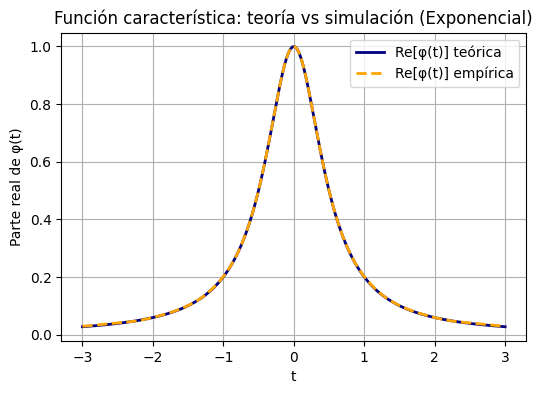

In [26]:
# Comparación entre la FC teórica y la FC empírica de una muestra Exponencial(λ)
lam = 0.5
np.random.seed(6)
u = np.random.uniform(0, 1, size=200_000)
x_sim = -np.log(1-u)/lam   # transformada inversa

ts = np.linspace(-3, 3, 200)
fc_teorica = lam/(lam - 1j*ts)
fc_empirica = np.array([np.mean(np.exp(1j*t*x_sim)) for t in ts])

fig, ax = plt.subplots()
ax.plot(ts, fc_teorica.real, color="navy", lw=2, label="Re[φ(t)] teórica")
ax.plot(ts, fc_empirica.real, "--", color="orange", lw=2, label="Re[φ(t)] empírica")
ax.set_xlabel("t"); ax.set_ylabel("Parte real de φ(t)")
ax.legend(); ax.set_title("Función característica: teoría vs simulación (Exponencial)")
plt.show()


Interpretación:

La parte real de la función característica empírica (calculada promediando $e^{itX}$ sobre la muestra simulada) sigue de cerca a la curva teórica $\lambda/(\lambda-it)$ para todo el rango de $t$ considerado. Esto ilustra que la FC empírica es un estimador consistente de la FC teórica, y refuerza la idea de que la FC "contiene toda la información" de la distribución, a diferencia de solo comparar un par de momentos.

### 3. Ley de los Grandes Números (LGN)

Sea $X_1, X_2, \dots$ una sucesión de variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con $E(X_i)=\mu$. La Ley de los Grandes Números afirma que el promedio muestral

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$$

converge a $\mu$ a medida que $n\to\infty$. Es la justificación matemática de por qué, al simular muchas observaciones y promediarlas, obtenemos una buena aproximación de la esperanza teórica.


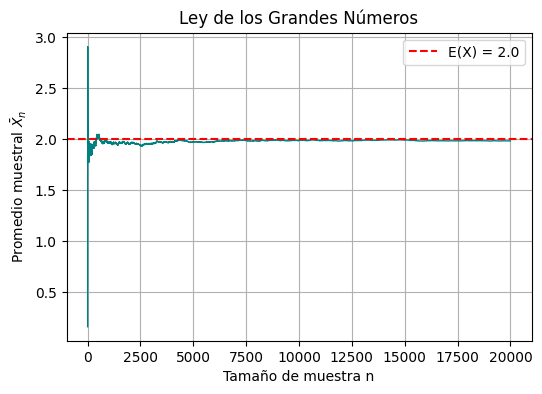

In [27]:
# Simulación de la LGN con una Exponencial(λ=0.5), generada por transformada inversa
lam = 0.5
mu = 1/lam
np.random.seed(7)

n_max = 20_000
u = np.random.uniform(0, 1, size=n_max)
x = -np.log(1-u)/lam                 # transformada inversa
promedios = np.cumsum(x) / np.arange(1, n_max+1)   # promedio acumulado

plt.plot(promedios, color="teal", lw=1)
plt.axhline(mu, color="red", linestyle="--", label=f"E(X) = {mu}")
plt.xlabel("Tamaño de muestra n"); plt.ylabel("Promedio muestral $\\bar{X}_n$")
plt.title("Ley de los Grandes Números")
plt.legend()
plt.show()


Interpretación:

Al inicio, con pocas observaciones el promedio muestral oscila bastante alrededor de la media teórica, pero conforme $n$ crece las oscilaciones se atenúan y la curva se estabiliza muy cerca de la línea horizontal $E(X)=2$. Esto es exactamente lo que predice la LGN: más datos implican una estimación más precisa y estable de la esperanza, y es la razón por la que, en las secciones anteriores, usar 100,000 simulaciones nos dio medias muestrales muy cercanas a los valores teóricos.

### 4. Teorema Central del Límite (TCL)

Sea $X_1, X_2, \dots, X_n$ una muestra i.i.d. con $E(X_i)=\mu$ y $Var(X_i)=\sigma^2 < \infty$. El Teorema Central del Límite establece que, para $n$ suficientemente grande, la media muestral estandarizada se aproxima a una distribución normal estándar:

$$Z_n = \frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \;\xrightarrow{d}\; N(0,1)$$

Equivalentemente, $\bar{X}_n$ se aproxima a $N(\mu, \sigma^2/n)$. Lo notable es que esto ocurre sin importar la forma de la distribución original de las $X_i$ (siempre que tenga varianza finita).


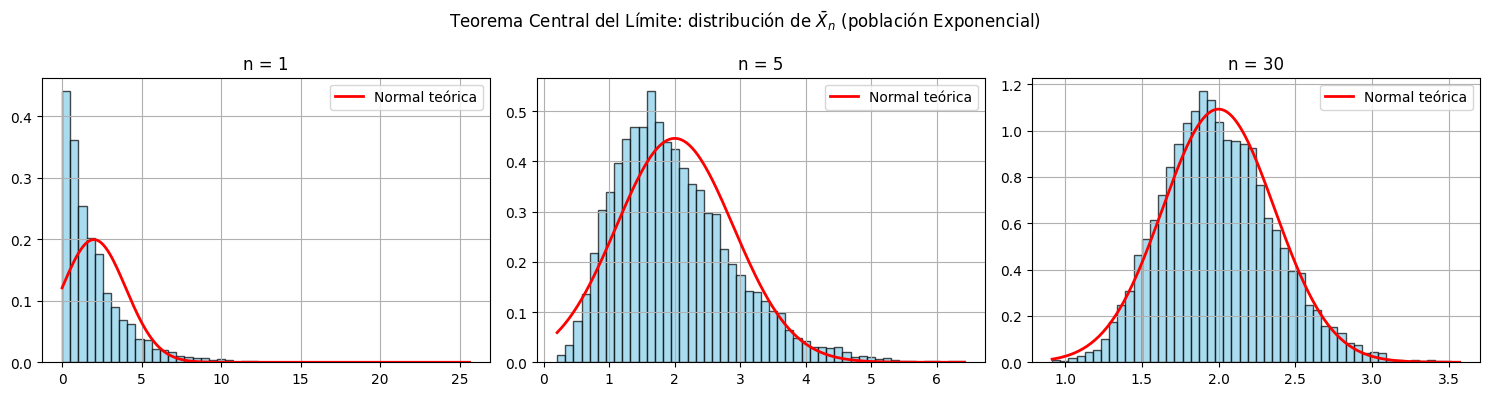

In [28]:
# Simulación del TCL usando una Exponencial(λ=0.5) (distribución muy asimétrica) generada por transformada inversa
lam = 0.5
mu, sigma2 = 1/lam, 1/lam**2

def muestra_exponencial(n, size):
    u = np.random.uniform(0, 1, size=(size, n))
    return -np.log(1-u)/lam   # transformada inversa

np.random.seed(8)
n_reps = 10_000

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, n in zip(axes, [1, 5, 30]):
    muestras = muestra_exponencial(n, n_reps)
    medias = muestras.mean(axis=1)

    ax.hist(medias, bins=50, density=True, color="skyblue", edgecolor="black", alpha=0.7)
    xx = np.linspace(medias.min(), medias.max(), 200)
    ax.plot(xx, stats.norm.pdf(xx, mu, np.sqrt(sigma2/n)), color="red", lw=2, label="Normal teórica")
    ax.set_title(f"n = {n}")
    ax.legend()

plt.suptitle("Teorema Central del Límite: distribución de $\\bar{X}_n$ (población Exponencial)")
plt.tight_layout()
plt.show()


Interpretación: 

Con $n=1$ el histograma de las medias muestrales es simplemente la densidad exponencial original (muy asimétrica, sin parecido a una campana). A medida que $n$ crece a 5 y luego a 30, el histograma de $\bar{X}_n$ se va pareciendo cada vez más a la curva Normal roja superpuesta (con media $\mu=2$ y varianza $\sigma^2/n$ decreciente). 

Esto demuestra de forma empírica el TCL: aunque la población original no sea normal, el promedio de muchas observaciones sí lo es aproximadamente, y la aproximación mejora al aumentar $n$. Este resultado es la base teórica de por qué usamos la Normal para construir intervalos de confianza y pruebas de hipótesis sobre medias muestrales.

## Conclusión

En el desarrollo de este notebook entendemos que las variables aleatorias son la arquitectura lógica indispensable para manejar la incertidumbre en mis análisis estadísticos. Las distribuciones discretas como Bernoulli, Binomial o Poisson, son las herramientas exactas para contar eventos o fracasos, mientras las continua, como la Normal o la Exponencial, en cambio, nos permiten modelar intervalos, medidas y tiempos de espera, no se trata solo de fórmulas, sino de representar matemáticamente escenarios de la vida real.   

Es increíble ver cómo todas están conectadas, por otro lado, al entrar a las variables continuas, notamos que aquí no podemos calcular la probabilidad de un punto exacto, sino de un intervalo o área bajo la curva, usar la simulación y ver cada una de estas funciones y modelos en gráficas confirman o nos dejan ver como trabajan la teoría y la simulación práctica coinciden casi a la perfección, reforzando conceptos y garantizando poder usar estos modelos y conocimientos al predecir o modelar.

Por último, comprendimos que herramientas como la Función Generadora de Momentos (FGM) y la Función Característica (FC), aunque suenan abstractas, son atajos matemáticos poderosos para encontrar esperanzas y varianzas sin tener que hacer sumas o integrales súper complejas, además de ayudar a demostrar el TCL.  En resumen, este notebook me enseñó que cada fenómeno aleatorio tiene una huella digital (su distribución), y conocer sus propiedades y momentos me permite predecir, simular y tomar decisiones informadas con bases sólidas.  

## Bibliografia 

- Rincón, L. (2019). Una introducción a la estadística inferencial (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México.

- Wackerly, D. D., Mendenhall III, W., & Scheaffer, R. L. (2010). Estadística matemática con aplicaciones (7ª ed.). México, D.F.: Cengage Learning.

- Rincón, L. (2014). Introducción a la probabilidad (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México.

- Ross, S. M. (2010). A First Course in Probability (8ª ed.). Upper Saddle River, NJ: Pearson Prentice Hall.

- Reyes Montes de Oca, C. C. (2026). Probabilidad: Variables Aleatorias Discretas y Continuas. FES Acatlán, UNAM.